# Phase 4b — Modeling: Side-Effect Topic Modeling (Model 2)

**Input:** cleaned `sideEffectsReview` document-term matrix (CountVectorizer)  
**Technique:** Latent Dirichlet Allocation (LDA)  
**Goal:** Extract 5–8 latent side-effect themes, label them from top keywords, and inspect document-topic assignments.

## Why LDA
LDA is a standard unsupervised text mining method for discovering mixed themes in short reviews without requiring labeled side-effect taxonomies. We sweep topic counts k=5..8 and select via **c_v coherence** (gensim), then manually name topics.

### Load Prepared DTM & Reviews

In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.max_open_warning'] = 50
import scipy.sparse as sp
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt

X_topic_dtm = sp.load_npz('../data/processed/X_topic_dtm.npz')
model2_train = pd.read_csv('../data/processed/model2_train_clean.csv')

with open('../data/processed/count_vectorizer.pkl', 'rb') as f:
    count_vectorizer = pickle.load(f)

feature_names = count_vectorizer.get_feature_names_out()
print('DTM shape:', X_topic_dtm.shape)
print('Reviews:', len(model2_train))
print('Vocabulary sample:', list(feature_names[:15]))
assert X_topic_dtm.shape[0] == len(model2_train)

DTM shape: (3019, 2000)
Reviews: 3019
Vocabulary sample: ['abdomen', 'abdominal', 'abdominal pain', 'ability', 'able', 'able sleep', 'abnormal', 'absence', 'absolutely', 'accompanied', 'ache', 'ached', 'achieve', 'aching', 'acid']


### Convert to Gensim Corpus & Sweep k = 5..8

In [2]:
from gensim import corpora, models
from gensim.models import CoherenceModel

# Build token lists from the count vocabulary (respect DTM features only)
vocab = list(feature_names)
id2word = corpora.Dictionary([vocab])
# Force dictionary ids to match column order of DTM
id2word = corpora.Dictionary()
id2word.token2id = {tok: i for i, tok in enumerate(vocab)}
id2word.id2token = {i: tok for i, tok in enumerate(vocab)}
id2word.dfs = {i: 1 for i in range(len(vocab))}  # placeholder; not used by LDA fit on corpus

# Build corpus from sparse DTM: list of (term_id, count)
X_csr = X_topic_dtm.tocsr()
corpus = []
texts_for_coherence = []
for i in range(X_csr.shape[0]):
    start, end = X_csr.indptr[i], X_csr.indptr[i + 1]
    idxs = X_csr.indices[start:end]
    vals = X_csr.data[start:end]
    bow = [(int(j), float(v)) for j, v in zip(idxs, vals)]
    corpus.append(bow)
    # Expand counts into token lists for coherence
    tokens = []
    for j, v in zip(idxs, vals):
        tokens.extend([vocab[j]] * int(v))
    texts_for_coherence.append(tokens)

print('Corpus docs:', len(corpus), '| empty bows:', sum(1 for b in corpus if not b))

Corpus docs: 3019 | empty bows: 0


k=5  coherence(c_v)=0.7264


k=6  coherence(c_v)=0.6884


k=7  coherence(c_v)=0.7123


k=8  coherence(c_v)=0.7114

Selected k=5 with coherence=0.7264


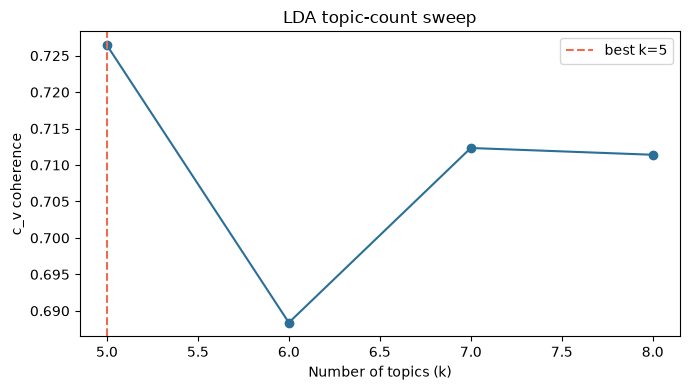

In [3]:
coherence_scores = {}
lda_models = {}

for k in range(5, 9):
    lda = models.LdaModel(
        corpus=corpus,
        id2word={i: t for i, t in enumerate(vocab)},
        num_topics=k,
        random_state=42,
        passes=10,
        iterations=100,
        alpha='auto',
        eta='auto',
        chunksize=500,
        eval_every=None,
    )
    cm = CoherenceModel(
        model=lda,
        texts=texts_for_coherence,
        dictionary=corpora.Dictionary(texts_for_coherence),
        coherence='c_v',
    )
    score = cm.get_coherence()
    coherence_scores[k] = score
    lda_models[k] = lda
    print(f'k={k}  coherence(c_v)={score:.4f}')

best_k = max(coherence_scores, key=coherence_scores.get)
print(f'\nSelected k={best_k} with coherence={coherence_scores[best_k]:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ks = list(coherence_scores.keys())
ax.plot(ks, [coherence_scores[k] for k in ks], marker='o', color='#2a6f97')
ax.axvline(best_k, color='#ee6c4d', linestyle='--', label=f'best k={best_k}')
ax.set_xlabel('Number of topics (k)')
ax.set_ylabel('c_v coherence')
ax.set_title('LDA topic-count sweep')
ax.legend()
plt.tight_layout()
plt.savefig('../visuals/model2_coherence_sweep.png', dpi=150)
plt.show()

### Top Keywords & Manual Topic Labels

In [4]:
lda = lda_models[best_k]

def topic_top_words(model, topic_id, n=12):
    return [w for w, _ in model.show_topic(topic_id, topn=n)]

print('Raw top keywords per topic:')
for t in range(best_k):
    words = topic_top_words(lda, t, n=12)
    print(f"Topic {t}: {', '.join(words)}")

Raw top keywords per topic:
Topic 0: first, stomach, bad, hour, mild, thing, take, day, dose, also, night, insomnia
Topic 1: side, effect, side effect, not, taking, none, drug, taken, took, dose, medication, high
Topic 2: pain, severe, extreme, finger, headache, nausea, dizziness, fatigue, tired, joint, day, nothing
Topic 3: not, time, skin, week, day, month, acne, get, would, great, take, even
Topic 4: weight, dry, increased, libido, gain, loss, mouth, patient, sexual, weight gain, dry mouth, mild


In [5]:
def suggest_label(words):
    """Keyword-cue suggestions to guide manual labeling."""
    wset = set(words)
    rules = [
        ({'nausea', 'vomit', 'vomiting', 'stomach', 'diarrhea', 'constipation', 'appetite', 'abdominal'},
         'GI / digestive effects'),
        ({'sleep', 'drowsy', 'drowsiness', 'tired', 'fatigue', 'insomnia', 'sleepy', 'sedation'},
         'Sleep / fatigue / sedation'),
        ({'skin', 'rash', 'itch', 'itchy', 'acne', 'hives'},
         'Skin / dermatologic effects'),
        ({'headache', 'dizzy', 'dizziness', 'migraine', 'lightheaded'},
         'Headache / dizziness'),
        ({'anxiety', 'mood', 'depression', 'irritable', 'panic', 'mental'},
         'Mood / psychiatric effects'),
        ({'weight', 'gain', 'hungry', 'libido', 'sexual', 'dry'},
         'Weight / sexual / dryness effects'),
        ({'pain', 'ache', 'muscle', 'joint', 'back', 'cramp', 'severe'},
         'Pain / severe systemic effects'),
        ({'none', 'nothing', 'experienced', 'side effect'},
         'Minimal / no notable side effects'),
    ]
    for cues, label in rules:
        if wset & cues:
            return label
    return 'General / mixed side effects'

topic_keywords = {t: topic_top_words(lda, t, n=12) for t in range(best_k)}

# Manual labels grounded in top keywords for the selected k (override heuristics)
MANUAL_TOPIC_LABELS = {
    0: 'Onset / GI discomfort & sleep disruption',
    1: 'Minimal / generic side-effect language',
    2: 'Severe pain, nausea, headache & fatigue',
    3: 'Skin / acne treatment effects',
    4: 'Weight, dryness & sexual side effects',
}

topic_labels = {}
for t in range(best_k):
    if best_k == 5 and t in MANUAL_TOPIC_LABELS:
        topic_labels[t] = MANUAL_TOPIC_LABELS[t]
    else:
        topic_labels[t] = suggest_label(topic_keywords[t])

print('Labeled topics:')
for t in range(best_k):
    print(f'Topic {t}: {topic_labels[t]}')
    print(f"  keywords: {', '.join(topic_keywords[t])}")



Labeled topics:
Topic 0: Onset / GI discomfort & sleep disruption
  keywords: first, stomach, bad, hour, mild, thing, take, day, dose, also, night, insomnia
Topic 1: Minimal / generic side-effect language
  keywords: side, effect, side effect, not, taking, none, drug, taken, took, dose, medication, high
Topic 2: Severe pain, nausea, headache & fatigue
  keywords: pain, severe, extreme, finger, headache, nausea, dizziness, fatigue, tired, joint, day, nothing
Topic 3: Skin / acne treatment effects
  keywords: not, time, skin, week, day, month, acne, get, would, great, take, even
Topic 4: Weight, dryness & sexual side effects
  keywords: weight, dry, increased, libido, gain, loss, mouth, patient, sexual, weight gain, dry mouth, mild


### Topic Keyword Bar Charts

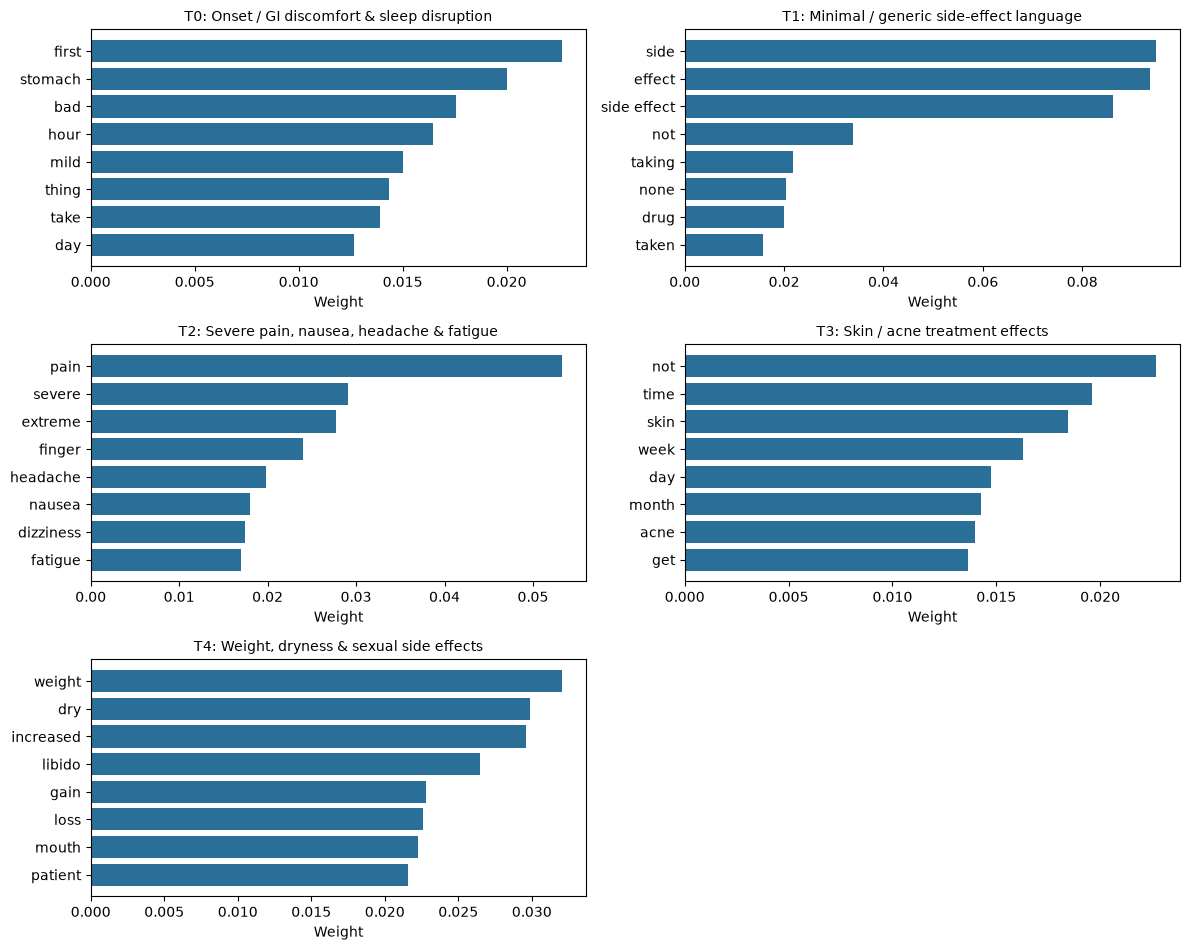

In [6]:
n_topics = best_k
ncols = 2
nrows = int(np.ceil(n_topics / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.2 * nrows))
axes = np.array(axes).reshape(-1)

for t in range(n_topics):
    pairs = lda.show_topic(t, topn=8)
    words = [w for w, _ in pairs][::-1]
    weights = [wt for _, wt in pairs][::-1]
    axes[t].barh(words, weights, color='#2a6f97')
    axes[t].set_title(f'T{t}: {topic_labels[t]}', fontsize=10)
    axes[t].set_xlabel('Weight')

for j in range(n_topics, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('../visuals/model2_topic_keywords.png', dpi=150)
plt.show()

### Document–Topic Distribution & Qualitative Spot Checks

Documents per dominant topic:
dominant_topic_label
Minimal / generic side-effect language      1130
Skin / acne treatment effects                846
Onset / GI discomfort & sleep disruption     489
Weight, dryness & sexual side effects        300
Severe pain, nausea, headache & fatigue      254
Name: count, dtype: int64


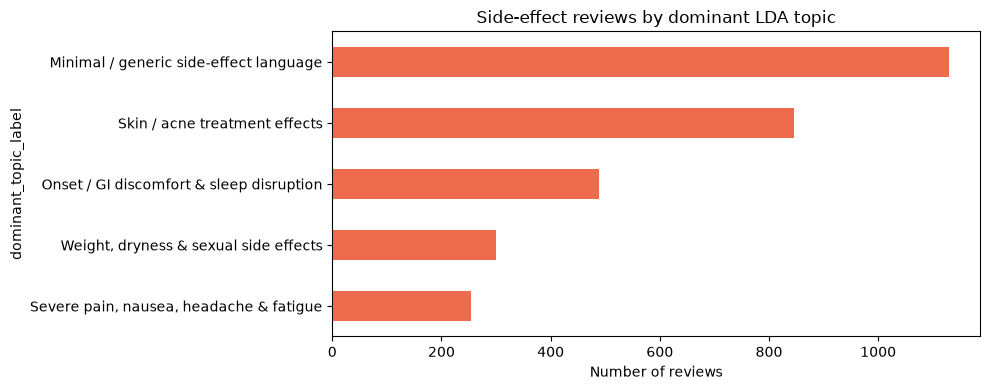


Sample reviews per topic (truncated):

--- Topic 0: Onset / GI discomfort & sleep disruption ---
  p=0.92 | Restless legs at night, insomnia, headache (sometimes pretty bad). Also, make sure you take it and THEN START PRODUCTIVE THINGS, otherwise you attention will be focused on whatever you are doing when it starts to work, i
  p=0.85 | I took the first dose without food liek the direction said and about 20 minutes later i was vomiting.

--- Topic 1: Minimal / generic side-effect language ---
  p=0.86 | On the plus side, I experienced no major side effects.  The possible effects can range from nausea to sexual dysfunction, but none were a problem.  However, it is possible to feel a sort of withdrawal.
  p=0.86 | On the plus side, I experienced no major side effects.  The possible effects can range from nausea to sexual dysfunction, but none were a problem.  However, it is possible to feel a sort of withdrawal.

--- Topic 2: Severe pain, nausea, headache & fatigue ---
  p=0.83 | Sever

In [7]:
# Dominant topic per document
dominant = []
dominant_prob = []
for bow in corpus:
    dist = lda.get_document_topics(bow, minimum_probability=0)
    dist = sorted(dist, key=lambda x: x[1], reverse=True)
    dominant.append(dist[0][0])
    dominant_prob.append(dist[0][1])

model2_train = model2_train.copy()
model2_train['dominant_topic'] = dominant
model2_train['dominant_topic_prob'] = dominant_prob
model2_train['dominant_topic_label'] = model2_train['dominant_topic'].map(topic_labels)

topic_counts = model2_train['dominant_topic_label'].value_counts()
print('Documents per dominant topic:')
print(topic_counts)

fig, ax = plt.subplots(figsize=(10, 4))
topic_counts.sort_values().plot(kind='barh', ax=ax, color='#ee6c4d')
ax.set_xlabel('Number of reviews')
ax.set_title('Side-effect reviews by dominant LDA topic')
plt.tight_layout()
plt.savefig('../visuals/model2_topic_distribution.png', dpi=150)
plt.show()

print('\nSample reviews per topic (truncated):')
for t in range(best_k):
    subset = model2_train[model2_train['dominant_topic'] == t].nlargest(2, 'dominant_topic_prob')
    print(f'\n--- Topic {t}: {topic_labels[t]} ---')
    for _, row in subset.iterrows():
        text = str(row.get('sideEffectsReview', ''))[:220].replace('\n', ' ')
        print(f"  p={row['dominant_topic_prob']:.2f} | {text}")

### Save Artifacts

In [8]:
Path('../data/processed').mkdir(parents=True, exist_ok=True)

lda.save('../data/processed/model2_lda.model')

topic_meta = pd.DataFrame([
    {
        'topic_id': t,
        'label': topic_labels[t],
        'top_keywords': ', '.join(topic_keywords[t]),
        'n_docs_dominant': int((model2_train['dominant_topic'] == t).sum()),
    }
    for t in range(best_k)
])
topic_meta.to_csv('../data/processed/model2_topic_labels.csv', index=False)

with open('../data/processed/model2_coherence_scores.pkl', 'wb') as f:
    pickle.dump({'scores': coherence_scores, 'best_k': best_k}, f)

model2_train[['dominant_topic', 'dominant_topic_prob', 'dominant_topic_label']].to_csv(
    '../data/processed/model2_doc_topics.csv', index=False
)

print('Saved LDA model, topic labels, coherence scores, and doc-topic assignments.')
print(topic_meta.to_string(index=False))

Saved LDA model, topic labels, coherence scores, and doc-topic assignments.
 topic_id                                    label                                                                                     top_keywords  n_docs_dominant
        0 Onset / GI discomfort & sleep disruption                   first, stomach, bad, hour, mild, thing, take, day, dose, also, night, insomnia              489
        1   Minimal / generic side-effect language          side, effect, side effect, not, taking, none, drug, taken, took, dose, medication, high             1130
        2  Severe pain, nausea, headache & fatigue  pain, severe, extreme, finger, headache, nausea, dizziness, fatigue, tired, joint, day, nothing              254
        3            Skin / acne treatment effects                           not, time, skin, week, day, month, acne, get, would, great, take, even              846
        4    Weight, dryness & sexual side effects weight, dry, increased, libido, gain, loss, mout

### Notes & Limitations

- Short side-effect reviews (median ~13 vectorized tokens) limit topic sharpness; some topics remain mixed.
- Bag-of-words LDA ignores negation scope and dosage context.
- Manual labels are interpretive; re-check if retrained on new data.
- Next: `05_evaluation.ipynb` consolidates Model 1 and Model 2 findings.